# DS4400 Final Project - Isabella Caruz

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("OnlineNewsPopularity.csv")

df = df.drop(columns=["url"])
df.columns = df.columns.str.strip()

df.head()



,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


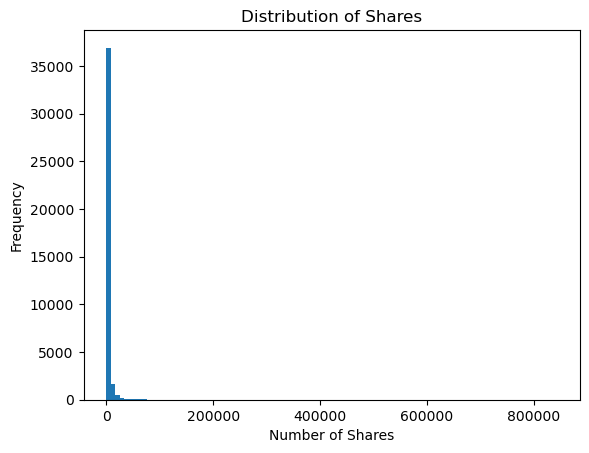

In [ ]:
plt.figure()
plt.hist(df["shares"], bins=100)
plt.title("Distribution of Shares")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")
plt.show()

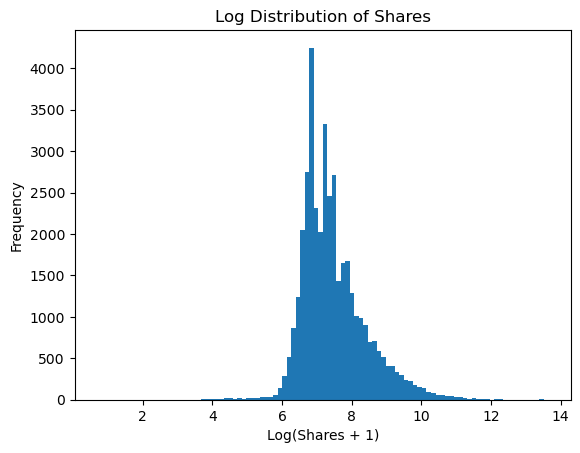

In [ ]:
plt.figure()
plt.hist(np.log1p(df["shares"]), bins=100)
plt.title("Log Distribution of Shares")
plt.xlabel("Log(Shares + 1)")
plt.ylabel("Frequency")
plt.show()

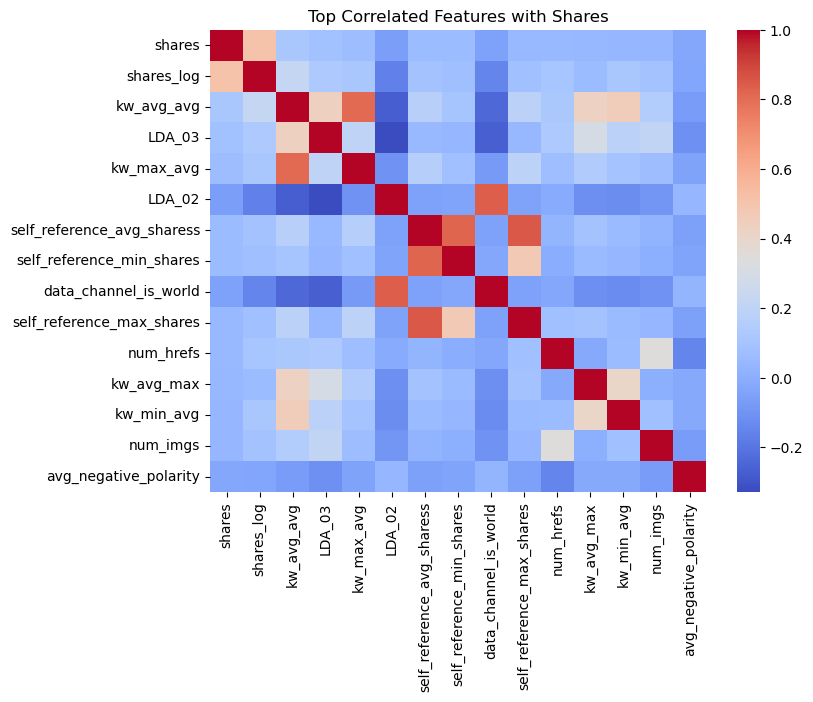

In [26]:
top_corr = corr["shares"].abs().sort_values(ascending=False).head(15).index
corr_subset = df[top_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_subset, annot=False, cmap="coolwarm")
plt.title("Top Correlated Features with Shares")
plt.show()

In [ ]:
df["shares_log"] = np.log1p(df["shares"])

X = df.drop(columns=["shares", "shares_log"])
y = df["shares_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

In [ ]:
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

In [ ]:
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
lasso_preds = lasso.predict(X_test_scaled)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [ ]:
def evaluate(y_true, preds):
    return {
        "MAE": mean_absolute_error(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "R2": r2_score(y_true, preds)
    }

print("Linear:", evaluate(y_test, lr_preds))
print("Ridge:", evaluate(y_test, ridge_preds))
print("Lasso:", evaluate(y_test, lasso_preds))
print("Random Forest:", evaluate(y_test, rf_preds))

Linear: {'MAE': 0.6443142521647088, 'RMSE': 0.8652111407352769, 'R2': 0.12670873583012365}
Ridge: {'MAE': 0.644152840832764, 'RMSE': 0.8649292161751923, 'R2': 0.12727775796130925}
Lasso: {'MAE': 0.70774428362982, 'RMSE': 0.9259058520210393, 'R2': -0.00011183802458414327}
Random Forest: {'MAE': 0.635737803557721, 'RMSE': 0.8473446927820506, 'R2': 0.16240295351994627}


In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top_feats = feat_imp.sort_values(ascending=False).head(5)
print(top_feats)

kw_avg_avg                    0.089511
timedelta                     0.041291
kw_max_avg                    0.039339
self_reference_avg_sharess    0.035172
kw_avg_max                    0.030100
dtype: float64


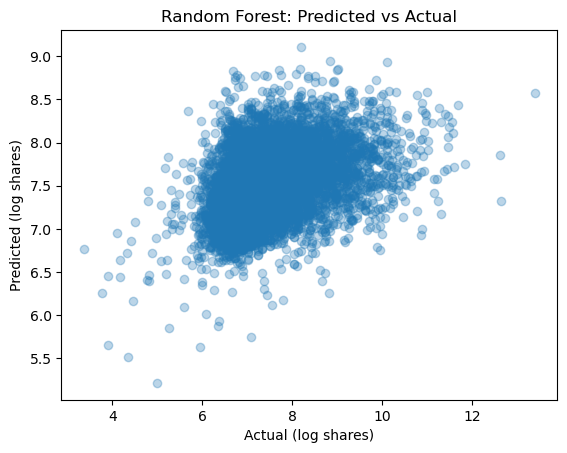

In [32]:
plt.figure()
plt.scatter(y_test, rf_preds, alpha=0.3)
plt.xlabel("Actual (log shares)")
plt.ylabel("Predicted (log shares)")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

In [ ]:
results_table = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Random Forest"],
    "MAE": [0.644, 0.644, 0.708, 0.636],
    "RMSE": [0.865, 0.865, 0.926, 0.847],
    "R²": [0.127, 0.127, 0.000, 0.162]
})

results_table

,Model,MAE,RMSE,R²
0,Linear Regression,0.644,0.865,0.127
1,Ridge,0.644,0.865,0.127
2,Lasso,0.708,0.926,0.000
3,Random Forest,0.636,0.847,0.162
